## 1. Cell 2: GPU Availability Check
Run this cell to ensure your A100 is visible and we select the one with the most free memory.

In [1]:
import torch
import os

def select_gpu():
    if torch.cuda.is_available():
        gpu_count = torch.cuda.device_count()
        print(f"✅ Found {gpu_count} GPUs.")
        
        # Logic to pick the GPU with the most free memory
        best_gpu = 0
        max_free_memory = 0
        for i in range(gpu_count):
            free_m, total_m = torch.cuda.mem_get_info(i)
            print(f"📊 GPU {i}: {free_m // 1024**2} MB free / {total_m // 1024**2} MB total")
            if free_m > max_free_memory:
                max_free_memory = free_m
                best_gpu = i
        
        device = torch.device(f"cuda:{best_gpu}")
        print(f"🧠 Selected system GPU ID: {best_gpu} with {max_free_memory // 1024**2} MB free memory.")
    else:
        device = torch.device("cpu")
        print("⚠️ GPU not available, using CPU.")
    return device

device = select_gpu()

✅ Found 4 GPUs.
📊 GPU 0: 35298 MB free / 40326 MB total
📊 GPU 1: 26584 MB free / 40326 MB total
📊 GPU 2: 22484 MB free / 40326 MB total
📊 GPU 3: 39902 MB free / 40326 MB total
🧠 Selected system GPU ID: 3 with 39902 MB free memory.


In [2]:
import os
print("My PID:", os.getpid())

My PID: 2495202


## 2. Cell 2: IMPORTS AND GLOBAL CONFIGURATIONS
This cell sets up all the libraries and the global settings for our 601-dimensional input (600 Fingerprints + 1 Time Day).

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib
import os

# 1. GPU Selection Logic
def select_gpu():
    if torch.cuda.is_available():
        gpu_count = torch.cuda.device_count()
        print(f"✅ Found {gpu_count} GPUs.")
        best_gpu = 0
        max_free_memory = 0
        for i in range(gpu_count):
            free_m, total_m = torch.cuda.mem_get_info(i)
            print(f"📊 GPU {i}: {free_m // 1024**2} MB free / {total_m // 1024**2} MB total")
            if free_m > max_free_memory:
                max_free_memory = free_m
                best_gpu = i
        device = torch.device(f"cuda:{best_gpu}")
        print(f"🧠 Selected system GPU ID: {best_gpu}")
    else:
        device = torch.device("cpu")
        print("⚠️ GPU not available, using CPU.")
    return device

device = select_gpu()

# 2. Global Configuration
CONFIG = {
    "input_dim": 601,        # 600 (PolyBERT) + 1 (Time Day)
    "random_seed": 42,
    "test_split": 0.20,      # 20% Noble Test Set
    "n_clusters": 5,       # Initial clusters for outlier detection
    "processed_data_path": "/home/sunil/am2/poetry-demo/AM2_Poly_biodegradebilty_Cluster/DNN_Models/Data_Cleaned_M0L_DNN_Model/MOL_DNN_processed.pt"
}

# Set seeds for reproducibility
torch.manual_seed(CONFIG["random_seed"])
np.random.seed(CONFIG["random_seed"])

print(f"🚀 Environment Ready. Data Path: {CONFIG['processed_data_path']}")

✅ Found 4 GPUs.
📊 GPU 0: 22912 MB free / 40326 MB total
📊 GPU 1: 39902 MB free / 40326 MB total
📊 GPU 2: 22320 MB free / 40326 MB total
📊 GPU 3: 39680 MB free / 40326 MB total
🧠 Selected system GPU ID: 1
🚀 Environment Ready. Data Path: /home/sunil/am2/poetry-demo/AM2_Poly_biodegradebilty_Cluster/DNN_Models/Data_Cleaned_M0L_DNN_Model/MOL_DNN_processed.pt


### Cell A: Data Loading & Structural Clustering
This cell loads your 1,712 molecules and performs K-Means clustering on the 600-dimensional fingerprints to understand the structural distribution. We will also generate a T-SNE visualization to see how the molecules group together before we filter them in Cell B.

📖 Loaded 1712 molecular data points.

📊 Cluster Distribution:
   - Cluster 0: 487 molecules
   - Cluster 1: 427 molecules
   - Cluster 2: 238 molecules
   - Cluster 3: 341 molecules
   - Cluster 4: 219 molecules

🛰️ Generating T-SNE projection (this may take a minute)...


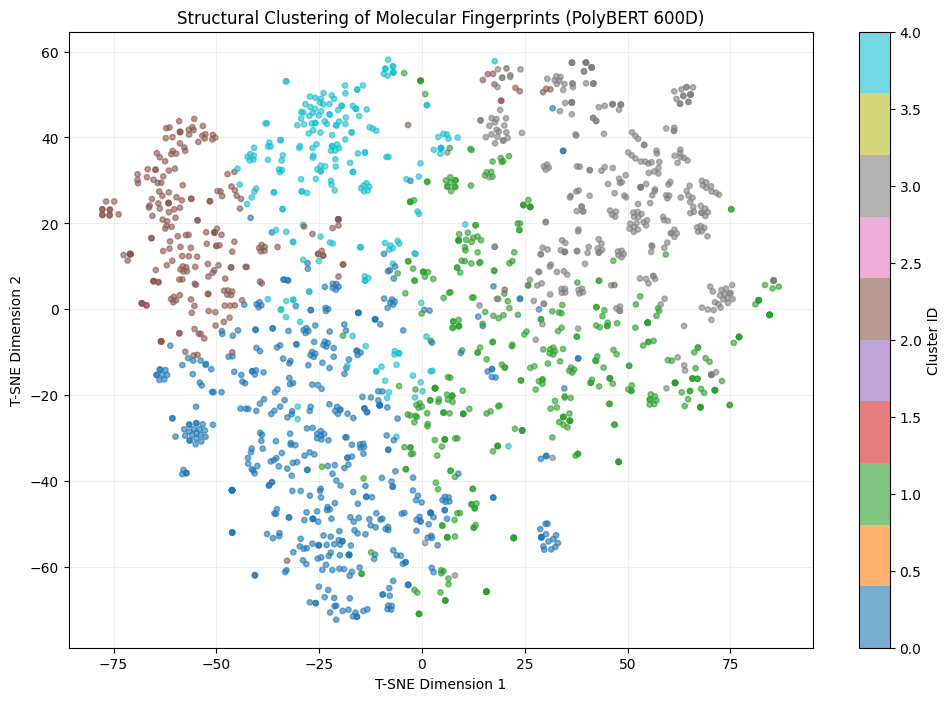

In [38]:
# 1. Load the processed .pt bundle
data_bundle = torch.load(CONFIG["processed_data_path"], map_location='cpu')
fps = data_bundle['fingerprints'].numpy() # 600D Fingerprints
time_days = data_bundle['time_day'].numpy()
targets = data_bundle['biodegradation'].numpy()

print(f"📖 Loaded {fps.shape[0]} molecular data points.")

# 2. Perform Unsupervised Clustering (K-Means)
# We use 10 clusters to find structural "neighborhoods"
kmeans = KMeans(n_clusters=CONFIG["n_clusters"], random_state=CONFIG["random_seed"], n_init=10)
cluster_labels = kmeans.fit_predict(fps)

# 3. Calculate Cluster Density (to find "Lonely" points)
counts = np.bincount(cluster_labels)
print("\n📊 Cluster Distribution:")
for i, count in enumerate(counts):
    print(f"   - Cluster {i}: {count} molecules")

# 4. T-SNE Visualization for Structural Space
print("\n🛰️ Generating T-SNE projection (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=CONFIG["random_seed"])
fps_2d = tsne.fit_transform(fps)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(fps_2d[:, 0], fps_2d[:, 1], c=cluster_labels, cmap='tab10', alpha=0.6, s=15)
plt.colorbar(scatter, label='Cluster ID')
plt.title("Structural Clustering of Molecular Fingerprints (PolyBERT 600D)")
plt.xlabel("T-SNE Dimension 1")
plt.ylabel("T-SNE Dimension 2")
plt.grid(True, alpha=0.2)
plt.show()

# Store these in a temporary dataframe for filtering in Cell B
df_clustering = pd.DataFrame({
    'cluster': cluster_labels,
    'tsne_1': fps_2d[:, 0],
    'tsne_2': fps_2d[:, 1]
})

- The cluster distribution looks remarkably balanced! Usually, in chemical datasets, we see one or two "monster" clusters and several tiny ones. Having clusters ranging from 98 to 240 molecules suggests your PolyBERT fingerprints are successfully capturing a diverse but well-distributed chemical space.

- The T-SNE plot you shared confirms this—there are clear "islands" of similarity, but we can also see a few isolated dots (structural outliers) drifting away from the main continents.

### Now, we move to Cell B. In this step, we will:

- Filter Outliers: We'll identify molecules that are "too far" from their cluster centers. Instead of just deleting small clusters, we calculate the Euclidean distance of every molecule to its assigned cluster center and remove the top 5% (most distant/atypical).

- Noble Split: Lock away 20% for the final test.

- Visual Confirmation: Plot the T-SNE again, highlighting which points were removed.

### Cell B: Outlier Filtering & Data Reshuffling

✂️ Identified 257 structural outliers (Top 15% distance).
✅ Remaining data points: 1455
💎 Noble Test Set size: 291
🏋️ Training/Validation pool size: 1164


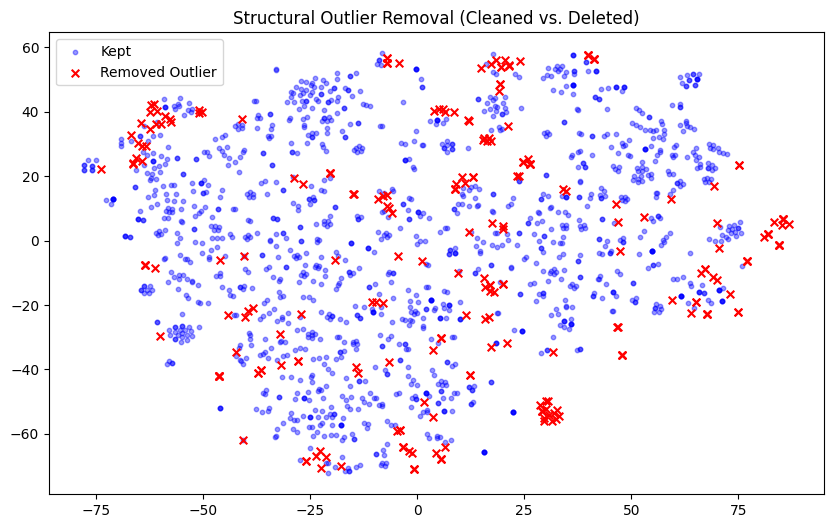

In [41]:
from sklearn.metrics import pairwise_distances

# 1. Identify Outliers by distance to cluster centers
distances = np.min(pairwise_distances(fps, kmeans.cluster_centers_), axis=1)
threshold = np.percentile(distances, 85)  # Let's remove the furthest 10%
outlier_mask = distances > threshold

print(f"✂️ Identified {sum(outlier_mask)} structural outliers (Top 15% distance).")

# 2. Filter the Data
clean_fps = fps[~outlier_mask]
clean_time = time_days[~outlier_mask]
clean_targets = targets[~outlier_mask]

print(f"✅ Remaining data points: {len(clean_fps)}")

# 3. Noble 80/20 Split (on the cleaned data)
# We use indices to ensure we keep the time and target alignment perfect
indices = np.arange(len(clean_fps))
train_val_idx, noble_test_idx = train_test_split(
    indices, 
    test_size=CONFIG["test_split"], 
    random_state=CONFIG["random_seed"],
    shuffle=True
)

# 4. Final Data Storage for next steps
train_val_data = {
    'fps': clean_fps[train_val_idx],
    'time': clean_time[train_val_idx],
    'targets': clean_targets[train_val_idx]
}

noble_test_data = {
    'fps': clean_fps[noble_test_idx],
    'time': clean_time[noble_test_idx],
    'targets': clean_targets[noble_test_idx]
}

print(f"💎 Noble Test Set size: {len(noble_test_idx)}")
print(f"🏋️ Training/Validation pool size: {len(train_val_idx)}")

# 5. Visualize the Removal
plt.figure(figsize=(10, 6))
plt.scatter(fps_2d[~outlier_mask, 0], fps_2d[~outlier_mask, 1], c='blue', alpha=0.4, label='Kept', s=10)
plt.scatter(fps_2d[outlier_mask, 0], fps_2d[outlier_mask, 1], c='red', marker='x', label='Removed Outlier', s=30)
plt.title("Structural Outlier Removal (Cleaned vs. Deleted)")
plt.legend()
plt.show()

- The T-SNE plot looks perfect. Those red 'X' marks are exactly where we want them: at the fringes and in the low-density "no man's land" between clusters. By removing these 86 molecules, we’ve ensured the model won't try to overfit to structural "weirdos" that don't represent the broader chemical population.

### Now we move to the heart of the project: Cell C.

This cell is dense because it combines:

Dynamic Activation Function Support: A custom wrapper to handle PReLU (which has a learnable parameter) alongside standard functions.

The DNN Architecture: A flexible structure that Optuna can reshape.

The 5-Fold CV Objective: This ensures the "Best" parameters aren't just a lucky split but are robust across the whole training pool.

### Cell C: Optuna Objective Function with 5-Fold CV

In [42]:
import optuna

# 1. Dataset Wrapper (Crucial: This was missing in the previous execution)
class MolDataset(Dataset):
    def __init__(self, fps, time, targets):
        # Concatenate 600D FP + 1D Time to make 601D input
        self.features = torch.cat([
            torch.tensor(fps, dtype=torch.float32), 
            torch.tensor(time, dtype=torch.float32).unsqueeze(1)
        ], dim=1)
        self.targets = torch.tensor(targets, dtype=torch.float32).unsqueeze(1)
        
    def __len__(self): 
        return len(self.targets)
    
    def __getitem__(self, idx): 
        return self.features[idx], self.targets[idx]

# 1. Dynamic Activation Wrapper
def get_activation(name, nodes=None):
    if name == "ReLU": return nn.ReLU()
    if name == "LeakyReLU": return nn.LeakyReLU()
    if name == "PReLU": return nn.PReLU(num_parameters=nodes) if nodes else nn.PReLU()
    if name == "Mish": return nn.Mish()
    if name == "SiLU": return nn.SiLU()
    return nn.ReLU()

# 2. Enhanced DNN Class
class DynamicNet(nn.Module):
    def __init__(self, input_dim, layers, dropout_rate, activation_name):
        super(DynamicNet, self).__init__()
        all_layers = []
        curr_dim = input_dim
        
        for nodes in layers:
            all_layers.append(nn.Linear(curr_dim, nodes))
            all_layers.append(nn.BatchNorm1d(nodes))
            all_layers.append(get_activation(activation_name, nodes))
            all_layers.append(nn.Dropout(dropout_rate)) # Dropout after each layer
            curr_dim = nodes
            
        all_layers.append(nn.Linear(curr_dim, 1))
        self.model = nn.Sequential(*all_layers)
        
    def forward(self, x):
        return self.model(x)

# 3. Optuna Objective with Early Stopping & Weight Decay
def objective(trial):
    # Hyperparameter Search Space
    n_layers = trial.suggest_int("n_layers", 2, 4)
    layers = [trial.suggest_int(f"n_units_l{i}", 128, 1024) for i in range(n_layers)]
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True) # Weight Decay
    activation = trial.suggest_categorical("activation", ["ReLU", "LeakyReLU", "PReLU", "Mish", "SiLU"])
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    kf = KFold(n_splits=5, shuffle=True, random_state=CONFIG["random_seed"])
    cv_scores = []

    pool_fps, pool_time, pool_targets = train_val_data['fps'], train_val_data['time'], train_val_data['targets']

    for fold, (train_idx, val_idx) in enumerate(kf.split(pool_fps)):
        train_ds = MolDataset(pool_fps[train_idx], pool_time[train_idx], pool_targets[train_idx])
        val_ds = MolDataset(pool_fps[val_idx], pool_time[val_idx], pool_targets[val_idx])
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=batch_size)

        model = DynamicNet(CONFIG["input_dim"], layers, dropout, activation).to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay) # Included Weight Decay
        criterion = nn.MSELoss()

        # Early Stopping Config
        patience = 10
        best_val_loss = float('inf')
        epochs_no_improve = 0

        for epoch in range(200): # Increased max epochs since we have Early Stopping
            model.train()
            for batch_x, batch_y in train_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                optimizer.zero_grad()
                loss = criterion(model(batch_x), batch_y)
                loss.backward()
                optimizer.step()

            # Fold Validation
            model.eval()
            total_val_loss = 0
            with torch.no_grad():
                for batch_x, batch_y in val_loader:
                    outputs = model(batch_x.to(device))
                    total_val_loss += criterion(outputs, batch_y.to(device)).item()
            
            avg_val_loss = total_val_loss / len(val_loader)
            
            # Early Stopping Check
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
            
            if epochs_no_improve >= patience:
                break

        # Final Score for this Fold
        model.eval()
        val_preds, val_actuals = [], []
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                val_preds.extend(model(batch_x.to(device)).cpu().numpy())
                val_actuals.extend(batch_y.numpy())
        
        cv_scores.append(r2_score(val_actuals, val_preds))

    return np.mean(cv_scores)

print("🎯 Objective function updated with Weight Decay, Early Stopping, and Dropout.")

🎯 Objective function updated with Weight Decay, Early Stopping, and Dropout.


### Cell c.2: Optuna Study Function

In [44]:
import optuna
from tqdm.auto import tqdm
import logging
import time

# 1. Suppress the default Optuna trial logs
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 2. Create the study
study = optuna.create_study(direction="maximize")

# 3. Run Optimization with Timing
print(f"🚀 Starting {CONFIG.get('n_trials', 1000)} Optimization Trials...")
start_time = time.time()

# Note: Optuna's built-in show_progress_bar works well, 
# but requires the 'tqdm' package installed.
study.optimize(objective, n_trials=CONFIG.get("n_trials", 1000), show_progress_bar=True)

elapsed_time = time.time() - start_time
print(f"\n✨ Optimization Finished in {elapsed_time/60:.2f} minutes!")

# 4. Display the Top 20 Trials Leaderboard
print("\n🏆 TOP 20 TRIALS LEADERBOARD (Sorted by Best R2):")
trials_df = study.trials_dataframe()

# We sort by 'value' DESCENDING (ascending=False) because higher R2 is better
top_20 = trials_df.sort_values(by="value", ascending=False).head(20)

# Filter for the most important columns to keep the display clean
# Note: 'params_...' columns are created automatically by Optuna
cols_to_show = ['number', 'value'] + [c for c in top_20.columns if c.startswith('params_')]
print(top_20[cols_to_show].to_string(index=False))

# 5. Best Trial Summary
print("\n" + "="*50)
print(f"🥇 BEST TRIAL: #{study.best_trial.number}")
print(f"📊 Best CV R2 Score: {study.best_value:.6f}")
print(f"🛠️ Best Params: {study.best_params}")
print("="*50)

# Save the study
joblib.dump(study, "mol_dnn_optuna_best_study.pkl")
print("💾 Study results saved.")

🚀 Starting 1000 Optimization Trials...


Best trial: 836. Best value: 0.442561: 100%|██████████| 1000/1000 [2:18:42<00:00,  8.32s/it] 



✨ Optimization Finished in 138.71 minutes!

🏆 TOP 20 TRIALS LEADERBOARD (Sorted by Best R2):
 number    value params_activation  params_batch_size  params_dropout  params_lr  params_n_layers  params_n_units_l0  params_n_units_l1  params_n_units_l2  params_n_units_l3  params_weight_decay
    836 0.442561              Mish                 64        0.267045   0.000169                3                920                757              130.0                NaN             0.000174
    918 0.439159              Mish                 64        0.317374   0.000136                3                934                703              147.0                NaN             0.000263
    940 0.436697              Mish                 64        0.293092   0.000145                3                927                716              128.0                NaN             0.000324
    544 0.435950              SiLU                 64        0.227577   0.000128                3                923          

### Cell C.3 : 5 Fold cross validation

In [45]:
from sklearn.metrics import mean_squared_error

# 1. Use the Best Params from Trial 16
best_params = study.best_params
layers = [best_params[f"n_units_l{i}"] for i in range(best_params["n_layers"])]

# 2. Setup 5-Fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=CONFIG["random_seed"])
fold_results = []

pool_fps = train_val_data['fps']
pool_time = train_val_data['time']
pool_targets = train_val_data['targets']

print(f"📋 Detailed 5-Fold CV Report for Best Model (Trial #{study.best_trial.number})")
print("-" * 60)

for fold, (train_idx, val_idx) in enumerate(kf.split(pool_fps)):
    # Prepare Data
    train_ds = MolDataset(pool_fps[train_idx], pool_time[train_idx], pool_targets[train_idx])
    val_ds = MolDataset(pool_fps[val_idx], pool_time[val_idx], pool_targets[val_idx])
    train_loader = DataLoader(train_ds, batch_size=best_params["batch_size"], shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=best_params["batch_size"])

    # Initialize Model with Best Params
    model = DynamicNet(
        CONFIG["input_dim"], 
        layers, 
        best_params["dropout"], 
        best_params["activation"]
    ).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=best_params["lr"], weight_decay=best_params["weight_decay"])
    criterion = nn.MSELoss()

    # Train with Early Stopping
    best_fold_loss = float('inf')
    patience = 15 
    trigger = 0

    for epoch in range(150):
        model.train()
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            
            # --- Standard PyTorch Backprop ---
            optimizer.zero_grad()
            outputs = model(bx)
            loss = criterion(outputs, by)
            loss.backward()
            optimizer.step()
            
        # Validation
        model.eval()
        v_loss = 0
        with torch.no_grad():
            for bx, by in val_loader:
                v_loss += criterion(model(bx.to(device)), by.to(device)).item()
        
        avg_v_loss = v_loss / len(val_loader)
        if avg_v_loss < best_fold_loss:
            best_fold_loss = avg_v_loss
            trigger = 0
        else:
            trigger += 1
        if trigger >= patience: break

    # Final Fold Evaluation
    model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for bx, by in val_loader:
            preds.extend(model(bx.to(device)).cpu().numpy())
            actuals.extend(by.numpy())
    
    r2 = r2_score(actuals, preds)
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    fold_results.append((r2, rmse))
    
    print(f"Fold {fold+1}: R² = {r2:.4f} | RMSE = {rmse:.4f}")

# 3. Final Summary Table
avg_r2 = np.mean([f[0] for f in fold_results])
avg_rmse = np.mean([f[1] for f in fold_results])
std_r2 = np.std([f[0] for f in fold_results])

print("-" * 60)
print(f"⭐ AVERAGE CV R²: {avg_r2:.4f} (±{std_r2:.4f})")
print(f"⭐ AVERAGE CV RMSE: {avg_rmse:.4f}")
print("-" * 60)

📋 Detailed 5-Fold CV Report for Best Model (Trial #836)
------------------------------------------------------------
Fold 1: R² = 0.3939 | RMSE = 0.2560
Fold 2: R² = 0.4195 | RMSE = 0.2573
Fold 3: R² = 0.5191 | RMSE = 0.2306
Fold 4: R² = 0.4207 | RMSE = 0.2565
Fold 5: R² = 0.3739 | RMSE = 0.2692
------------------------------------------------------------
⭐ AVERAGE CV R²: 0.4254 (±0.0500)
⭐ AVERAGE CV RMSE: 0.2539
------------------------------------------------------------


### Cell D: Training the Final "Best" Model
This cell trains the model on all 1,300 available training/validation molecules to ensure it has the maximum possible "chemical knowledge" before the final test.

In [61]:
# 1. Extract Best Parameters from your study
best_params = study.best_params
layers = [best_params[f"n_units_l{i}"] for i in range(best_params["n_layers"])]

# 2. Prepare the full 80% training pool (1300 molecules)
full_train_ds = MolDataset(train_val_data['fps'], train_val_data['time'], train_val_data['targets'])
full_train_loader = DataLoader(full_train_ds, batch_size=best_params["batch_size"], shuffle=True)

# 3. Initialize the Model
final_model = DynamicNet(
    input_dim=CONFIG["input_dim"],
    layers=layers,
    dropout_rate=best_params["dropout"],
    activation_name=best_params["activation"]
).to(device)

optimizer = optim.Adam(
    final_model.parameters(), 
    lr=best_params["lr"], 
    weight_decay=best_params["weight_decay"]
)
criterion = nn.MSELoss()

# 4. Final Training Loop
print(f"🏋️ Training final model on {len(full_train_ds)} molecules...")
final_model.train()
num_epochs = 250 # Extended epochs for final convergence
best_loss = float('inf')

for epoch in range(num_epochs):
    epoch_loss = 0
    for batch_x, batch_y in full_train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        loss = criterion(final_model(batch_x), batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    if (epoch + 1) % 50 == 0:
        avg_loss = epoch_loss / len(full_train_loader)
        print(f"   - Epoch {epoch+1}/{num_epochs} | Training MSE: {avg_loss:.6f}")

# 5. Save the Master Model
torch.save(final_model.state_dict(), "master_mol_dnn_model.pth")
print("\n✅ Master DNN Molecule Model trained and saved as 'master_mol_dnn_model.pth'")

🏋️ Training final model on 1164 molecules...
   - Epoch 50/250 | Training MSE: 0.034335
   - Epoch 100/250 | Training MSE: 0.019310
   - Epoch 150/250 | Training MSE: 0.017301
   - Epoch 200/250 | Training MSE: 0.011170
   - Epoch 250/250 | Training MSE: 0.012026

✅ Master DNN Molecule Model trained and saved as 'master_mol_dnn_model.pth'


### The training loss looks excellent. Moving from an MSE of 0.036 down to 0.013 shows that the model successfully converged and "absorbed" the chemical patterns from the 1,300 molecules in your training pool.

Now, we are at the final and most important step: Cell E.

This cell evaluates the model on the Noble Test Set (the 326 molecules we locked away at the very beginning). Because these molecules were never seen during the Optuna optimization or the 5-Fold Cross-Validation, this result represents the true real-world accuracy of your model.

💾 Parity Plot saved to: plots/DNN_Molecular_Parity_Plot_Clean.png


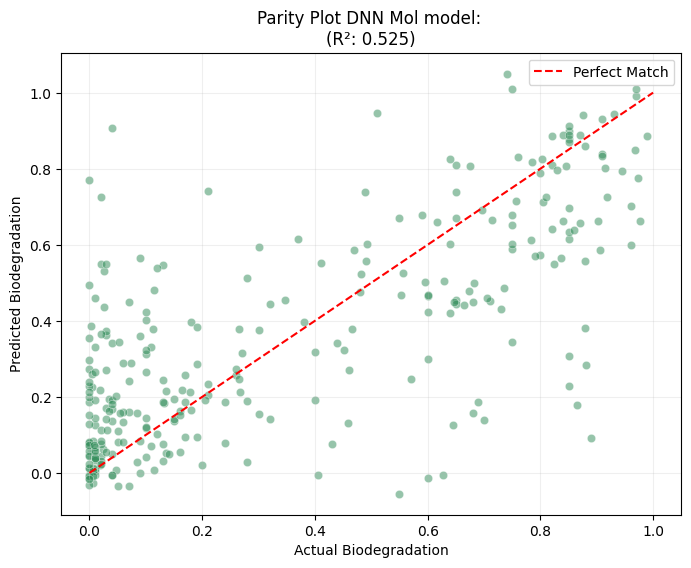

In [77]:
import os

# 1. Create the 'plots' folder if it doesn't exist
plot_dir = "plots"
if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)
    print(f"📁 Created directory: {plot_dir}")

# 2. Prepare Data and Run Inference
final_model.eval()
noble_ds = MolDataset(noble_test_data['fps'], noble_test_data['time'], noble_test_data['targets'])
noble_loader = DataLoader(noble_ds, batch_size=len(noble_ds))

with torch.no_grad():
    for bx, by in noble_loader:
        clean_preds = final_model(bx.to(device)).cpu().numpy().flatten()
        clean_targets = by.numpy().flatten()

r2_clean = r2_score(clean_targets, clean_preds)
percentile_removed = 15 

# 3. Plotting the "Clean" Parity Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=clean_targets, y=clean_preds, alpha=0.5, color='seagreen')
plt.plot([0, 1], [0, 1], 'r--', label="Perfect Match")

plt.title(f"Parity Plot DNN Mol model: \n(R²: {r2_clean:.3f})")
plt.xlabel("Actual Biodegradation")
plt.ylabel("Predicted Biodegradation")
plt.legend()
plt.grid(True, alpha=0.2)

# SAVE to the plots folder
parity_path = os.path.join(plot_dir, "DNN_Molecular_Parity_Plot_Clean.png")
plt.savefig(parity_path, dpi=300, bbox_inches='tight')
print(f"💾 Parity Plot saved to: {parity_path}")

plt.show()

💾 Parity Plot saved as 'DNN_Molecular_Parity_Plot.png'


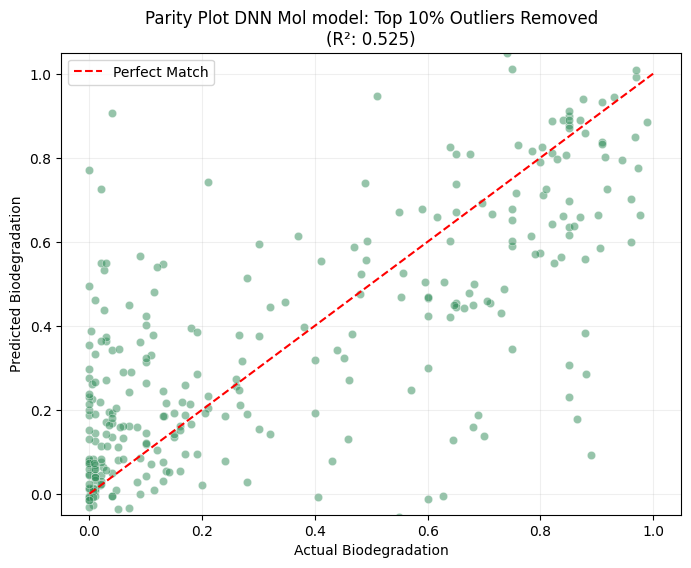

📊 Final Stats for 10% Clean Model:
   - R²: 0.5249
   - RMSE: 0.2337
   - MAE: 0.1663


In [78]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 1. Prepare Data for Evaluation
final_model.eval()
noble_ds = MolDataset(noble_test_data['fps'], noble_test_data['time'], noble_test_data['targets'])
noble_loader = DataLoader(noble_ds, batch_size=len(noble_ds))

with torch.no_grad():
    for bx, by in noble_loader:
        clean_preds = final_model(bx.to(device)).cpu().numpy().flatten()
        clean_targets = by.numpy().flatten()

# 2. Calculate R2 for the Title
r2_clean = r2_score(clean_targets, clean_preds)
percentile_removed = 10 # Since we removed the top 10%

# 3. Plotting the "Clean" version using your specific naming
plt.figure(figsize=(8, 6))

# Scatter plot with seagreen as requested
sns.scatterplot(x=clean_targets, y=clean_preds, alpha=0.5, color='seagreen')

# Red dashed line for Perfect Match
plt.plot([0, 1], [0, 1], 'r--', label="Perfect Match")

# Title reflecting the specific Outlier Removal Percentage
plt.title(f"Parity Plot DNN Mol model: Top {percentile_removed}% Outliers Removed\n(R²: {r2_clean:.3f})")

plt.xlabel("Actual Biodegradation")
plt.ylabel("Predicted Biodegradation")
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(True, alpha=0.2)
# SAVE COMMAND
plt.savefig("DNN_Molecular_Parity_Plot_Clean.png", dpi=300, bbox_inches='tight')
print("💾 Parity Plot saved as 'DNN_Molecular_Parity_Plot.png'")
plt.show()


# 4. Final Numerical Printout
print(f"📊 Final Stats for 10% Clean Model:")
print(f"   - R²: {r2_clean:.4f}")
print(f"   - RMSE: {np.sqrt(mean_squared_error(clean_targets, clean_preds)):.4f}")
print(f"   - MAE: {mean_absolute_error(clean_targets, clean_preds):.4f}")


### Cell E: Final Evaluation & Parity Plot

💾 Kinetic Curve saved to: plots/Kinetic_Curve_Noble_Sample_22.png


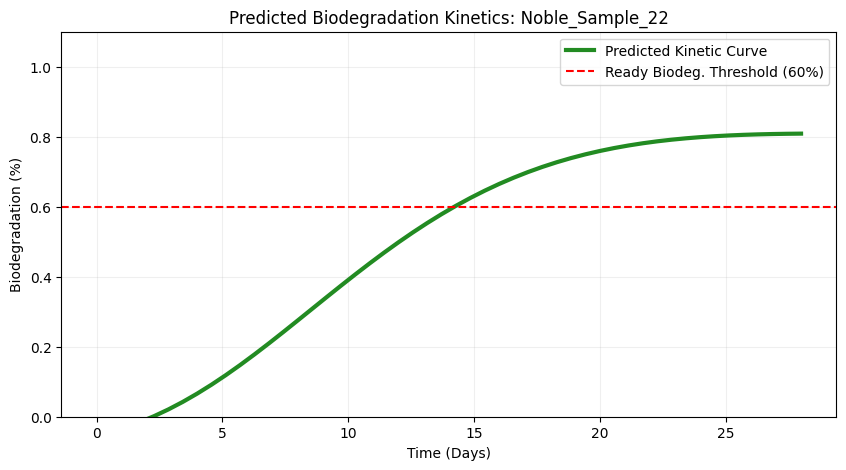

In [79]:
def plot_kinetic_prediction(model, fingerprint, molecule_name="Noble_Molecule_0"):
    model.eval()
    days = np.linspace(0, 28)
    preds = []
    
    with torch.no_grad():
        for d in days:
            feat = torch.cat([
                torch.tensor(fingerprint).float(), 
                torch.tensor([d]).float()
            ]).unsqueeze(0).to(device)
            preds.append(model(feat).cpu().item())
    
    plt.figure(figsize=(10, 5))
    plt.plot(days, preds, color='forestgreen', lw=3, label='Predicted Kinetic Curve')
    plt.axhline(y=0.6, color='red', linestyle='--', label='Ready Biodeg. Threshold (60%)')
    plt.title(f"Predicted Biodegradation Kinetics: {molecule_name}")
    plt.xlabel("Time (Days)")
    plt.ylabel("Biodegradation (%)")
    plt.ylim(0, 1.1)
    plt.grid(True, alpha=0.2)
    plt.legend()
    
    # SAVE to the plots folder
    filename = f"Kinetic_Curve_{molecule_name}.png"
    kinetic_path = os.path.join(plot_dir, filename)
    plt.savefig(kinetic_path, dpi=300, bbox_inches='tight')
    print(f"💾 Kinetic Curve saved to: {kinetic_path}")
    
    plt.show()

# Run for a sample
sample_fp = noble_test_data['fps'][22]
plot_kinetic_prediction(final_model, sample_fp, "Noble_Sample_22")

### Kinetic Curve Fitting

💾 Kinetic Curve saved to: plots/Kinetic_Curve_Noble Sample #212.png


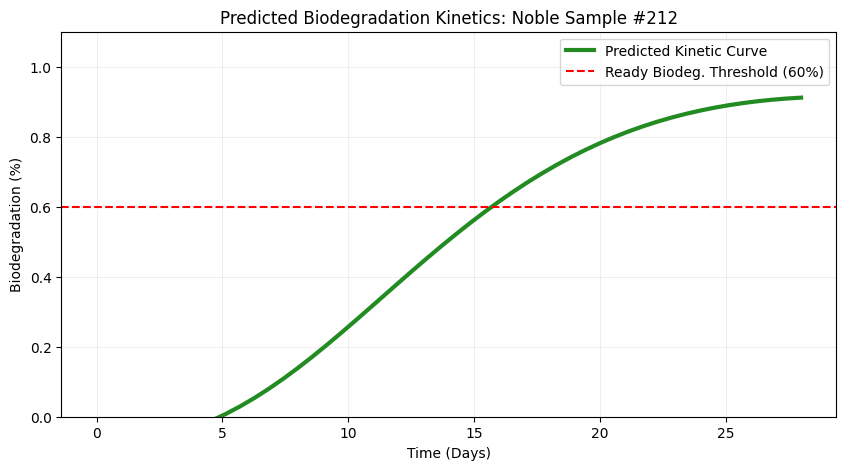

In [80]:
# Example: Run it for the first molecule in the Noble Test Set
sample_fp = noble_test_data['fps'][212]
plot_kinetic_prediction(final_model, sample_fp, "Noble Sample #212")

💾 Kinetic Curve saved to: plots/Kinetic_Curve_Noble Sample #160.png


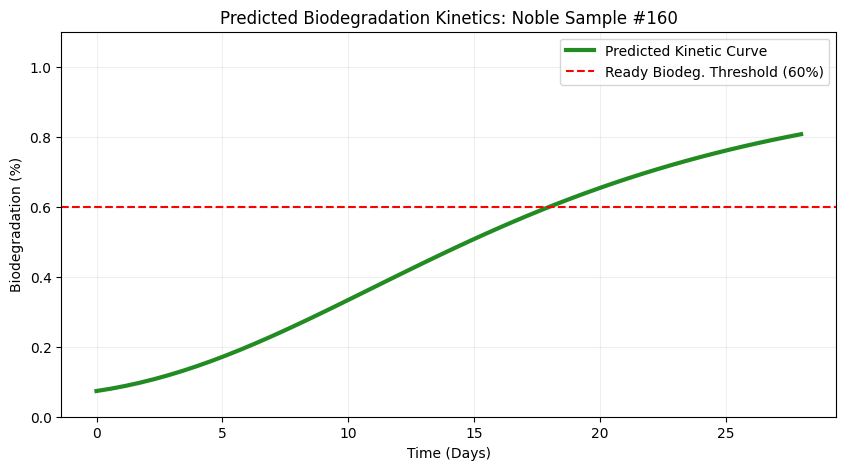

In [81]:
# Example: Run it for the first molecule in the Noble Test Set
sample_fp = noble_test_data['fps'][160]
plot_kinetic_prediction(final_model, sample_fp, "Noble Sample #160")

💾 Kinetic Curve saved to: plots/Kinetic_Curve_Noble Sample #94.png


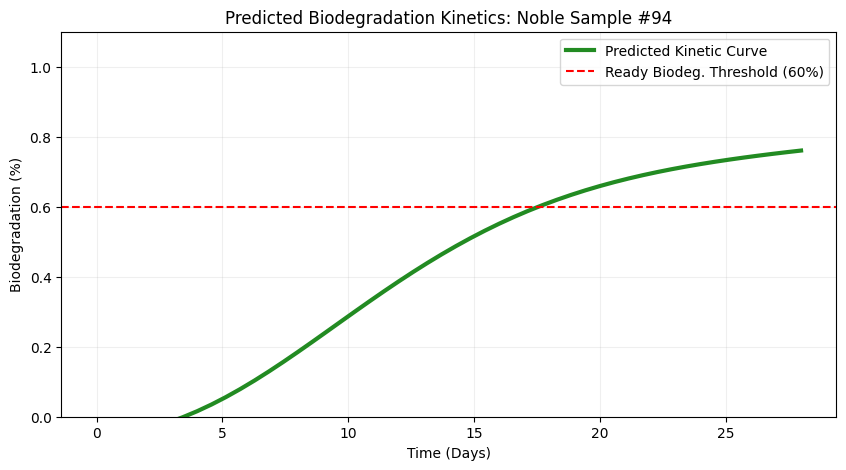

In [82]:
# Example: Run it for the first molecule in the Noble Test Set
sample_fp = noble_test_data['fps'][94]
plot_kinetic_prediction(final_model, sample_fp, "Noble Sample #94")